In [2]:
import numpy as np
import cv2
from copy import deepcopy
from gpiozero import PhaseEnableMotor
from time import sleep
#from cv_functions import *
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches


i = list(filter(lambda x: x.endswith('jpg'), os.listdir('..')))
i

['WIN_20250410_07_01_53_Pro.jpg',
 'WIN_20250410_07_01_57_Pro.jpg',
 'WIN_20250410_07_26_26_Pro.jpg',
 'WIN_20250410_07_26_31_Pro.jpg',
 'WIN_20250410_20_58_46_Pro.jpg',
 'WIN_20250410_20_58_53_Pro.jpg',
 'WIN_20250410_20_58_57_Pro.jpg',
 'WIN_20250410_20_59_01_Pro.jpg',
 'WIN_20250410_20_59_06_Pro.jpg',
 'WIN_20250410_20_59_10_Pro.jpg',
 'WIN_20250410_20_59_14_Pro.jpg',
 'WIN_20250410_20_59_19_Pro.jpg',
 'WIN_20250410_20_59_24_Pro.jpg',
 'WIN_20250410_20_59_29_Pro.jpg',
 'WIN_20250410_20_59_32_Pro.jpg',
 'WIN_20250410_20_59_52_Pro.jpg',
 'WIN_20250410_21_00_01_Pro.jpg',
 'WIN_20250410_21_00_11_Pro.jpg',
 'WIN_20250410_21_00_25_Pro.jpg']

In [50]:
def determineBoardCorners(frame, val = 4):
    # Our operations on the frame come here
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    ### detects corners ###
    # right now only tracks 4 at a time i think
    corners = cv2.goodFeaturesToTrack(gray,val,0.01,20)#, useHarrisDetector=True, k=0.1)
    #print(cv2.KeyPoint(corners[0][0][0], corners[0][0][1], 3).pt, corners[0], )
    print(cv2.boundingRect(corners))
    corners = np.sort(np.int32(corners.reshape(val,2)), axis=0)
    #corners = np.intp(corners) # array of corners?
    if False:
        ### getting contours in image ###
        # includes all values above 100
        # basically turns image into binary white/black depending on value
        ret,thresh = cv2.threshold(gray,1,100,cv2.THRESH_BINARY)

        contours,hierarchy = cv2.findContours(thresh, 1, 2)
        cnt = np.float32(contours[0])
        #v2.drawContours(frame, contours, -1, (0,255,0), 2)
        board_corners = []
        for i in corners:
            x = int(i[0][0])
            y = int(i[0][1])
            dist = cv2.pointPolygonTest(cnt,(x,y),True)
            if dist:
                board_corners.append(i[0])
        # finding min and max corners
        max = [0,0]
        min = [1000,1000]
        for i in board_corners:
            x = int(i[0])
            y = int(i[1])
            if (x < min[0]) and (y < min[1]):
                min = i
            if(x > max[0]) and (y > max[1]):
                max = i
        # # calculating size of each square on board
        width_x = max[0] - min[0]
        height_y = max[1] - min[1]

        print(max, min, height_y, width_x)

    return corners

(406, 160, 433, 390)


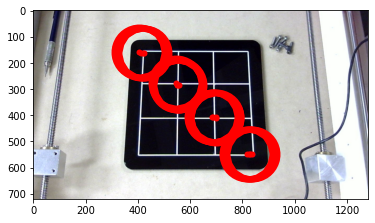

In [51]:
BOARD_SQUARE_SIZE = 20

img = cv2.imread(f'../{i[4]}')
corners = determineBoardCorners(img, 16)#[:8, :]
#print(corners)
x, y, w, h = cv2.boundingRect(corners)
fig, ax = plt.subplots(1)
ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
for c in corners:
    ax.scatter(c[0], c[1], lw=50, c="red")
#ax.add_patch( patches.Rectangle((x, y), w, h, linewidth=10, edgecolor='b', facecolor='none',angle=0))
plt.show()

In [24]:
corners

array([[548., 408.],
       [414., 408.],
       [557., 277.],
       [685., 161.],
       [546., 548.],
       [838., 549.],
       [420., 284.],
       [406., 549.],
       [687., 284.],
       [818., 161.],
       [697., 408.],
       [700., 548.],
       [830., 409.],
       [824., 284.],
       [425., 160.],
       [552., 161.]], dtype=float32)

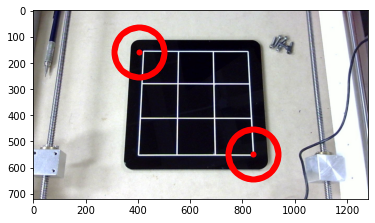

In [134]:
approx = cv2.approxPolyN(corners, 4)[0]
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
if len(approx) == 4:
   x, y, w, h = cv2.boundingRect(approx)
   plt.scatter(x, y, lw=50, c="red")
   plt.scatter(x+w, y+h, lw=50, c="red")
#    ratio= float(w)/h
#    print(ratio)
#    if ratio>=0.9 and ratio<=1.1:
#       print('Square')
#    else:
#       print('Rectangle')
plt.show()


In [ ]:
#corners = np.float32([ [575, 150], [975, 75], [1100, 425], [610, 525]])
#print(corners.shape, np.array([[0, 0], [BOARD_SQUARE_SIZE, 0], [0, BOARD_SQUARE_SIZE], [BOARD_SQUARE_SIZE, BOARD_SQUARE_SIZE]]).shape)

#M = getPerspectiveTransform(corners)
#plt.imshow(cv2.warpPerspective(img,M,(200,200)))
#plt.show()

{'orange': [[768, 470], [765, 324]], 'blue': []}


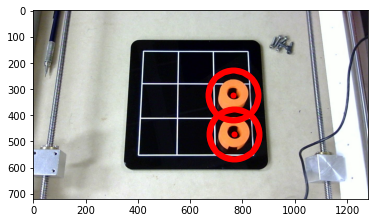

In [3]:
pieces = detectBoardPieceLocations(img)
print(pieces)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
for c in pieces['orange']:
    plt.scatter(c[0], c[1], lw=50, c="red")

plt.show()   


{'orange': [{'x': 706, 'y': 407, 'w': 124, 'h': 126}, {'x': 742, 'y': 442, 'w': 47, 'h': 47}, {'x': 706, 'y': 262, 'w': 119, 'h': 125}, {'x': 743, 'y': 297, 'w': 42, 'h': 42}], 'blue': []}


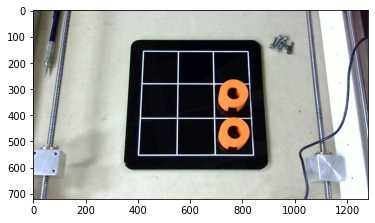

In [3]:
pieces = detectBoardPieceLocations(img)
print(pieces)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))


plt.show()   


In [9]:
np.linalg.norm([768 - 765, 420 - 465])

45.09988913511872

In [34]:
board = np.array([['', '', ''], ['', '', ''], ['', '', '']])
board

array([['', '', ''],
       ['', '', ''],
       ['', '', '']], dtype='<U1')

In [ ]:
for x in range(5):
    print('move')
    if check_win_condition(board) != '':
        print('WIN ACHIEVED', check_win_condition(board), '\n', board)
        break
    b_old = deepcopy(board)
    m = tic_tac_toe_logic_v2(board, 'x')
    board[m] = 'x'
    #rand_index = np.random.randint(0, len(np.where(board == '')[0]))
    #m2 = (np.where(board == '')[0][rand_index], np.where(board == '')[1][rand_index])
    m2 = 
    board[m2] = 'o'
    print(b_old, '\n', m, m2, '\n', board)
    


move
WIN ACHIEVED x 
 [['o' 'x' '']
 ['' 'x' '']
 ['o' 'x' 'o']]


In [1]:
import numpy as np

In [4]:
v = np.array([
        ['', '', ''],
        ['', '', ''],
        ['', '', ''],
    ])
v.shape

(3, 3)

In [9]:
v[(2, 1)] = 's'
v

array([['', '', ''],
       ['', '', ''],
       ['', 's', '']], dtype='<U1')

In [11]:
len((2, 1))

2